In [1]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing

VBM = VBMicrolensing.VBMicrolensing() # Instance to VBMicroLensing
import MulensModel as mm
from scipy.ndimage import map_coordinates

import csv
import warnings

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

In [2]:
class _MyBinaryLens(mm.BinaryLensPointSourceWM95Magnification):
    """Custom BinaryLens class potentially for modifications or extensions."""
    def __init__(self, q, s):
        # Initialize the parent MulensModel.BinaryLens
        self.s = s

        parameters = {'q': q, 's': s, 't_0': 0, 't_E': 1, 'u_0': 0.006, 'alpha': 0}
        model_params = mm.ModelParameters(parameters=parameters)

        traj = mm.Trajectory(times=0, parameters=model_params)

        super().__init__(trajectory=traj)

    def get_n_images(self, x, y):
        """
        Calculates the positions of images for a source at position (x, y).
        Relies on the _verify_polynomial_roots method from the parent class.
        """
        # The length of the list of roots corresponds to the number of images
        magnification = self._get_1_magnification(x, y, separation=self.s)

        # Getting image positions with the origin at the planet (0, 0)
        results = np.array(self._verify_polynomial_roots())

        # Shifting image positions to have origin at star
        for i in range(len(results)):
            results[i] += self.s + 0.0j

        return magnification, results
    
def _separate_circles(points, q, s):
    """
    Separate points into three circles.
    
    Parameters
    ----------
    points : Numpy NDArray
        Array of shape (N, 2) with all points
    q : float
        Planet to star mass ratio
    s : float
        x-coordinate of the off-center circle centroid (y = 0)
    
    Returns
    -------
    off_center : Numpy NDArray
        Points belonging to the off-center circle
    small_origin : Numpy NDArray
        Points belonging to the smaller origin-centered circle (avg radius < 1)
    large_origin : Numpy NDArray
        Points belonging to the larger origin-centered circle (avg radius > 1)
    """
    # Off-center circle parameters
    off_center = np.array([s, 0])
    off_radius = np.sqrt(q)

    # Distance of each point to off-center centroid
    d_off = np.linalg.norm(points - off_center, axis=1)

    # Assign off-center points if their radius is close to expected
    mask_off = np.abs(d_off - off_radius) < off_radius
    off_circle = points[mask_off]

    # Remaining points are origin-centered
    origin_points = points[~mask_off]

    # Compute radii of all origin-centered points
    r_origin = np.linalg.norm(origin_points, axis=1)

    # Split into two groups: below 1 and above 1
    small_mask = r_origin < 1
    small_origin = origin_points[small_mask]
    large_origin = origin_points[~small_mask]

    # (Optional) sanity check: swap if mislabeled
    if np.mean(np.linalg.norm(small_origin, axis=1)) > np.mean(np.linalg.norm(large_origin, axis=1)):
        small_origin, large_origin = large_origin, small_origin

    return off_circle, small_origin, large_origin

def _image_calculator(u, q, s):
    '''
    Calculates the major and minor radii for an annulus for a given source ring of radius u and binary lens configuration.

    Parameters
    ----------
    u : float
        Radius of source ring in units of Einstein radius
    q : float
        Planet to star mass ratio
    s : float
        Distance between star and planet in units of Einstein radius
    
    Returns
    -------
    y_plus : float
        Major image radius in units of Einstein radius
    y_minus : float
        Minor image radius in units of Einstein radius
    min_mag : float
        Minimum magnification in the source ring
    '''
    # Defining center of mass
    center_of_mass = np.array([q*s / (1 + q), 0])

    # Defining ring slightly larger than magnification map extent
    thetas = np.linspace(0, 2*np.pi, 1000, endpoint=False)
    xs = u * np.cos(thetas)
    ys = u * np.sin(thetas)

    # Initializing MulensModel binary lens
    model = _MyBinaryLens(q, s)

    # Defining lists to hold all image positions and magnifications
    all_points = []
    ring_magnifications = []

    # Iterating through all source positions in ring
    for x, y in zip(xs, ys):
        # Calculating corresponding magnifications and image positions
        magnification, image_positions = model.get_n_images(x - center_of_mass[0], y - center_of_mass[1])

        # Storing all image positions
        for image_position in image_positions:
            all_points.append([image_position.real, image_position.imag])

        # Storing magnifications
        ring_magnifications.append(magnification)

    # Converting to Numpy arrays
    all_points = np.array(all_points)
    ring_magnifications = np.array(ring_magnifications)

    # Separating points into three critical curves: off-centered circle around planet, smaller origin-centered circle, larger origin-centered circle
    offset_circle, small_circle, large_circle = _separate_circles(all_points, q, s)

    # Calculating polar coordinates of the points of each circle
    small_rs = np.sqrt(small_circle[:, 0]**2 + small_circle[:, 1]**2)
    small_thetas = np.arctan2(small_circle[:, 1], small_circle[:, 0]) * 180 / np.pi

    big_rs = np.sqrt(large_circle[:, 0]**2 + large_circle[:, 1]**2)
    big_thetas = np.arctan2(large_circle[:, 1], large_circle[:, 0]) * 180 / np.pi

    # Averaging radii of each circle to get y+ and y-
    # y+ is the average radius of the larger origin-centered circle
    # y- is the average radius of the smaller origin-centered circle
    y_plus = np.mean(big_rs)
    y_minus = np.mean(small_rs)

    return y_plus, y_minus, np.min(ring_magnifications)

def ang_width_calculator(lens_att: list | np.ndarray, pixels_in_small_source: int = 10, cm_offset: str | tuple | list = [0, 0], cm_translation: tuple | list = [0, 0]):
    '''
    Calculates the angular width of the magnification map using Equations 8-10 in https://arxiv.org/pdf/astro-ph/0505363.

    Parameters
    ----------
    lens_att : list
        Passed through via passed_params dict
    pixels_in_small_source : int, optional
        Number of pixels to cover the diameter of the smallest source. Default is 10
    cm_offset : str or tuple or list, optional
        Center of mass offset to be added to caustic positions. If 'auto', then the center of mass of each star-planet combination is used. Default is [0, 0]
    cm_translation : tuple or list, optional
        Center of mass translation to be applied to caustic positions. Default is [0, 0]

    Returns
    -------
    pixels : int
        Number of pixels along one side of the square magnification map
    ang_width : float
        Angular width of ray sampling region
    (qs, ss) : tuple of lists
        Mass ratios and separations of each star-planet combination
    points : Lx4x2 NDArray
        Locations of caustic cusps in the inertial frame
    (max_source_radius, min_source_radius) : tuple of floats
        Maximum and minimum source radii to be used for the simulation
    '''
    lens_att = np.array(lens_att)
    
    # Number of lens objects
    L = np.shape(lens_att)[0]

    # If radii
    if np.shape(lens_att)[1] == 4:
        mass_ind = 3
    else:
        mass_ind = 2

    # Initializing maximum distance from origin list
    max_dist_rot = []
    max_dist = []
    points = np.zeros(shape=(L-1, 4, 2))

    caustic_sizes = []

    qs = []
    ss = []

    # Calculating the center of masses of each individual star-planet combination
    lens_CMs_rot = np.zeros(shape=(L-1, 2))
    
    if L == 1:
        raise ValueError('Only one lens object detected. Cannot calculate angular width for single lens using this function.')

    else:
        for i, lens in enumerate(lens_att[1:]):
            two_lenses = np.array([lens_att[0], lens])

            # Finding which index the bigger mass was passed in (primary lens)
            big_mass = np.where(two_lenses[:, mass_ind] == np.max(two_lenses[:, mass_ind]))[0][0]

            # Secondary lens
            small_mass = int(not big_mass)

            # Defining unit source vector
            uhat = [1, 0]

            # Defining unit binary axis vector (from primary to secondary lens)
            v = [two_lenses[small_mass, 0] - two_lenses[big_mass, 0], two_lenses[small_mass, 1] - two_lenses[big_mass, 1]]
            vhat = v / np.linalg.norm(v)

            # Finding counterclockwise angle between binary axis and source trajectory (alpha)
            if vhat[0] > 0 and vhat[1] > 0:
                alpha = np.arctan(vhat[1]/vhat[0])
            elif vhat[0] < 0 and vhat[1] > 0:
                alpha = np.pi + np.arctan(vhat[1]/vhat[0])
            elif vhat[0] < 0 and vhat[1] < 0:
                alpha = np.pi + np.arctan(vhat[1]/vhat[0])
            elif vhat[0] > 0 and vhat[1] < 0:
                alpha = np.arctan(vhat[1]/vhat[0])
            elif vhat[0] > 0 and vhat[1] == 0:
                alpha = 0
            elif vhat[0] == 0 and vhat[1] > 0:
                alpha = np.pi/2
            elif vhat[0] < 0 and vhat[1] == 0:
                alpha = np.pi
            elif vhat[0] == 0 and vhat[1] < 0:
                alpha = -np.pi/2

            # Calculating distance between lenses (s)
            s = np.linalg.norm(v)
            ss.append(s)

            # Calculating mass ratio between lenses (q)
            q = two_lenses[small_mass, mass_ind] / two_lenses[big_mass, mass_ind]
            qs.append(q)

            # Calculating center of mass in binary axis
            lens_CMs_rot[i, 0] = q*s / (1 + q)

            # Creating rotation matrix
            cos, sin = np.cos(alpha), np.sin(alpha)
            Rot = np.array([[cos, -sin], [sin, cos]])

            # Finding cos(phi_c) - Equation 10
            cos_phi_c = 3/4 * (s + s**-1) * (1 - np.sqrt(1 - 32/9*(s + s**-1)**-2))

            # Finding phi_c through arccos
            phi_c = np.arccos(cos_phi_c)

            if cm_offset == 'auto':
                lens_CM = lens_CMs_rot[i]

            # Finding positive x and negative x positions - Equation 8
            x_pos_rot = q / ((1 + s)*(1 + s**-1)) - lens_CMs_rot[i, 0]
            x_neg_rot = -q / ((1 - s)*(1 - s**-1)) - lens_CMs_rot[i, 0]

            # Finding positive y and negative y positions - Equation 9
            y_pos_rot = (2*q * np.abs(np.sin(phi_c)**3)) / (s + s**-1 - 2*cos_phi_c)**2 - lens_CMs_rot[i, 1]
            y_neg_rot = -(2*q * np.abs(np.sin(phi_c)**3)) / (s + s**-1 - 2*cos_phi_c)**2 - lens_CMs_rot[i, 1]

            # Storing the maximum distance from the origin of the caustic
            max_dist_rot.append(np.max(np.abs(np.array([x_pos_rot, x_neg_rot, y_pos_rot, y_neg_rot]))))

            # Rotating bounding points back from binary axis to inertial axis
            x_pos = np.dot(Rot, np.array([x_pos_rot, 0])) + lens_CM - cm_translation
            x_neg = np.dot(Rot, np.array([x_neg_rot, 0])) + lens_CM - cm_translation

            y_pos = np.dot(Rot, np.array([0, y_pos_rot])) # + lens_CM - cm_translation
            y_neg = np.dot(Rot, np.array([0, y_neg_rot])) # + lens_CM - cm_translation

            # Finding maximum distance from the origin and storing it
            points[i, :, :] = np.array([x_pos, x_neg, y_pos, y_neg])
            max_dist.append(np.max(np.abs(points[i, :, :])))

            width = abs(x_pos_rot - x_neg_rot)
            height = abs(y_pos_rot - y_neg_rot)

            caustic_sizes.append(max(width, height))

    # Finding the maximum distance of a cusp from the origin among all caustics
    max_cusp_distance = np.max(max_dist)

    # Finding maximum caustic size
    max_caustic_size = np.max(caustic_sizes)

    # Finding maximum source radius
    max_source_radius = (10 * max_caustic_size) / 2
    min_source_radius = max_source_radius / 100

    # Adding source diameter as padding
    ang_width_source = 2 * (max_cusp_distance + 2.1*max_source_radius)

    # Angular width regardless of source size
    ang_width_nosource = 4 * max_cusp_distance

    # Choose largest width:
    ang_width = max(ang_width_source, ang_width_nosource)

    # Making map twice as wide as the minimum required
    # ang_width *= 2

    # Determining the number of pixels such that the source radius is covered by at least a certain number of pixels
    ang_res = min_source_radius*2 / pixels_in_small_source
    pixels = int(ang_width / ang_res) + 1

    return pixels, ang_width, (qs, ss), points, (max_source_radius, min_source_radius)

def annulus_bounds_calculator(ang_width: float, qs: list, ss: list, annulus_center: list | np.ndarray = None):
    '''
    Calculates the annulus bounds and minimum magnification for a given angular width and lens configuration.

    Parameters
    ----------
    ang_width : float
        Angular width of ray sampling region
    qs : list
        Mass ratios of each star-planet combination. For a single lens, pass None
    ss : list
        Separations of each star-planet combination. For a single lens, pass None
    annulus_center : list, optional
        Center of annulus. Default is None, which means no offset is applied

    Returns
    -------
    (y_plus, y_minus) : tuple
        Major and minor image positions
    min_mag : float
        Minimum magnification in the source ring
    '''
    # Number of lens objects
    if qs is None or ss is None:
        L = 1
    else:
        L = len(qs) + 1

    # Finding the maximum distance from the origin of magnification map
    u = 1.05 * ang_width / np.sqrt(2)
    
    if annulus_center is not None:
        annulus_center = -np.array(annulus_center)
        
        if annulus_center[0] > 0 and annulus_center[1] > 0:
            angle = np.arctan(annulus_center[1]/annulus_center[0])
        elif annulus_center[0] < 0 and annulus_center[1] > 0:
            angle = np.pi + np.arctan(annulus_center[1]/annulus_center[0])
        elif annulus_center[0] < 0 and annulus_center[1] < 0:
            angle = np.pi + np.arctan(annulus_center[1]/annulus_center[0])
        elif annulus_center[0] > 0 and annulus_center[1] < 0:
            angle = np.arctan(annulus_center[1]/annulus_center[0])
        elif annulus_center[0] > 0 and annulus_center[1] == 0:
            angle = 0
        elif annulus_center[0] == 0 and annulus_center[1] > 0:
            angle = np.pi/2
        elif annulus_center[0] < 0 and annulus_center[1] == 0:
            angle = np.pi
        elif annulus_center[0] == 0 and annulus_center[1] < 0:
            angle = -np.pi/2

        u = np.sqrt(u**2 + np.linalg.norm(annulus_center)**2 - 2*u*np.linalg.norm(annulus_center)*np.cos(angle - np.pi/4))
    
    # Finding major and minor image positions (y+ > 0 and y- < 0)
    if L == 1:
        # For a single lens
        y_plus = np.abs(0.5 * (u + np.sqrt(u**2 + 4)))
        y_minus = np.abs(0.5 * (u - np.sqrt(u**2 + 4)))

        # Calculate analytic magnification for a single lens
        min_mag = (u**2 + 2) / (u * np.sqrt(u**2 + 4))

    else:
        # For multiple lenses, find the annulus bounds for each star-planet combination and take the bounds that give the largest annulus
        y_pluses = []
        y_minuses = []
        min_mags = []

        for q, s in zip(qs, ss):
            y_plus, y_minus, min_mag = _image_calculator(u, q, s)
            y_pluses.append(y_plus)
            y_minuses.append(y_minus)
            min_mags.append(min_mag)

        y_plus = np.max(y_pluses)
        y_minus = np.min(y_minuses)

        # Taking the minimum magnification among all star-planet combinations
        min_mag = np.min(min_mags)

    return (y_plus, y_minus), min_mag

def num_ray_calculator(pixels: int, ang_width: float, y_plus: float, y_minus: float, min_mag: float, delta: float = 0.01, r_theta_ratio: int | float = 4):
    '''
    Calculates the number of rays to shoot in r and theta directions to achieve the desired error in the image plane.

    Parameters
    ----------
    pixels : int
        Number of pixels along one side of the square magnification map
    ang_width : float
        Angular width of ray sampling region
    y_plus : float
        Major image position
    y_minus : float
        Minor image position
    min_mag : float
        Minimum magnification in the source ring
    delta : float, optional
        Desired error in the source plane in units of Einstein radius. Default is 0.01
    r_theta_ratio : int or float, optional
        Ratio of number of rays in r to number of rays in theta. Default is 4

    Returns
    -------
    num_r : int
        Number of rays in radial direction
    num_theta : int
        Number of rays in angular direction
    '''
    # Width of pixel
    dx = ang_width / (pixels - 1)

    # Area of annulus
    a_ann = (np.pi * (y_plus**2 - y_minus**2))

    # Ray density in annulus
    n_image = 1 / (min_mag * dx**2 * delta**2)

    # Total number of rays
    N_rays = n_image * a_ann

    # Number of rays in theta
    num_theta = int(np.ceil(np.sqrt(N_rays / r_theta_ratio)))

    # Number of rays in r
    num_r = int(np.ceil(r_theta_ratio * num_theta))

    return num_r, num_theta

def einstein_to_index(x_pix, y_pix, ang_width, pixels):
    '''
    Converts scientific coordinates to pixel indices.

    Parameters
    ----------
    x_pix : float
        x coordinate in scientific coordinates
    y_pix : float
        y coordinate in scientific coordinates
    ang_width : float
        Angular width of magnification map
    pixels : int
        Number of pixels along one side of the square magnification map

    Returns
    -------
    (x_ind, y_ind) : tuple
        Pixel indices corresponding to the scientific coordinates
    '''
    ang_res = ang_width / (pixels - 1)

    if pixels % 2 == 0:  # even number of pixels
        x_ind = (x_pix + ang_width / 2) / ang_res
        y_ind = (ang_width / 2 + y_pix) / ang_res
    
    else:  # odd number of pixels
        x_ind = (x_pix + ang_width / 2) / ang_res
        y_ind = (ang_width / 2 + y_pix) / ang_res

    return x_ind, y_ind

def index_to_einstein(x_ind, y_ind, ang_width, pixels):
    '''
    Converts pixel indices to scientific coordinates.

    Parameters
    ----------
    x_ind : float
        x pixel index
    y_ind : float
        y pixel index
    ang_width : float
        Angular width of magnification map
    pixels : int
        Number of pixels along one side of the square magnification map

    Returns
    -------
    (x_pix, y_pix) : tuple
        Scientific coordinates corresponding to the pixel indices
    '''
    ang_res = ang_width / (pixels - 1)

    if pixels % 2 == 0:
        # Even number of pixels
        x_pix = -ang_width / 2 + x_ind * ang_res
        y_pix = -ang_width / 2 + y_ind * ang_res
    else:
        # Odd number of pixels
        x_pix = -ang_width / 2 + x_ind * ang_res
        y_pix = -ang_width / 2 + y_ind * ang_res

    return x_pix, y_pix

def lightcurve_calculator(u_0, alpha, t_0, t_E, ang_width: float, map_array: np.ndarray, lens_CM: tuple | np.ndarray=(0, 0), offset: tuple | np.ndarray=(0, 0), n_samples: int=1e4):
    '''
    Calculates the light curve by interpolating magnification values along a line.

    Parameters
    ----------
    u_0 : float
        Impact parameter from the lens center of mass
    alpha : float
        Angle of source trajectory from x axis in degrees
    t_0 : float
        Time of closest approach to lens center of mass
    t_E : float
        Einstein crossing time
    ang_width : float
        Angular width of magnification map
    map_array : 2D NDArray
        Magnification map array
    lens_CM: 2-element tuple or NDArray
        Center of mass of lens system in scientific coordinates
    offset : 2-element tuple or NDArray, optional
        Current origin offset from star position in scientific coordinates
    n_samples : int, optional
        Number of interpolated samples along the trajectory

    Returns
    -------
    intersections : 2x2 NDArray
        First row is starting point, second row is ending point (in scientific coordinates)
    (xs, ys) : tuple of 1D NDArrays
        Scientific coordinates of the line
    times : 1D NDArray
        Array of time values along trajectory
    line_values : 1D NDArray
        Interpolated magnification values along the line
    '''
    # Ensure n_samples is an integer
    n_samples = int(n_samples)

    # Convert alpha to radians
    alpha = np.deg2rad(alpha)
    
    # Defining intersections list
    intersections = []

    # Center of trajectory in inertial frame
    x0_inert = u_0 * np.sin(alpha)
    y0_inert = -u_0 * np.cos(alpha)

    # Convert to COM frame (scientific coordinates)
    x0 = x0_inert - offset[0] + lens_CM[0]
    y0 = y0_inert - offset[1] + lens_CM[1]

    dx = np.cos(alpha)
    dy = np.sin(alpha)

    # Find entry and exit points of the trajectory through the square map
    if dx == 0:
        # Vertical line case
        if -ang_width/2 <= x0 <= ang_width/2:
            intersections.append((x0, ang_width/2))
            intersections.append((x0, -ang_width/2))
    elif dy == 0:
        # Horizontal line case
        if -ang_width/2 <= y0 <= ang_width/2:
            intersections.append((ang_width/2, y0))
            intersections.append((-ang_width/2, y0))
    else:
        # General case
        for x_edge in [ang_width/2, -ang_width/2]:
            t = (x_edge - x0) / dx
            y = y0 + t*dy
            if -ang_width/2 <= y <= ang_width/2:
                intersections.append((x_edge, y))

        for y_edge in [ang_width/2, -ang_width/2]:
            t = (y_edge - y0) / dy
            x = x0 + t*dx
            if -ang_width/2 <= x <= ang_width/2:
                intersections.append((x, y_edge))

    if len(intersections) < 2:
        raise ValueError("Trajectory does not intersect the magnification map bounds.")

    intersections = np.array(intersections[:2])  # First two valid ones

    # Get start and end in scientific coordinates
    start = intersections[0]
    end = intersections[1]

    # Calculating start and end times in real time units
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        t_start_x = ((u_0 * np.sin(alpha) - start[0]) / np.cos(alpha))*t_E + t_0
        t_start_y = -((u_0 * np.cos(alpha) + start[1]) / np.sin(alpha))*t_E + t_0

        t_end_x = ((u_0 * np.sin(alpha) - end[0]) / np.cos(alpha))*t_E + t_0
        t_end_y = -((u_0 * np.cos(alpha) + end[1]) / np.sin(alpha))*t_E + t_0

    # Finding correct start and end times
    if alpha == 0 or alpha == 180:
        t_start = t_start_x
        t_end = t_end_x
    elif alpha == 90 or alpha == 270:
        t_start = t_start_y
        t_end = t_end_y
    else:
        t_start = np.mean([t_start_x, t_start_y])
        t_end = np.mean([t_end_x, t_end_y])

    # Defining time range for the trajectory
    times = np.linspace(t_start, t_end, n_samples)
    
    # Normalizing time to Einstein time units
    taus = (times - t_0) / t_E

    # Calculating x and y coordinates along trajectory
    xs = u_0*np.sin(alpha) - taus*np.cos(alpha)
    ys = -u_0*np.cos(alpha) - taus*np.sin(alpha)

    # Convert to pixel indices (float) for interpolation
    pixels = map_array.shape[0]
    x_idx, y_idx = einstein_to_index(xs, ys, ang_width, pixels)

    # Interpolate brightnesses
    coords = np.vstack([y_idx, x_idx])  # row-major (y first)
    line_values = map_coordinates(map_array, coords, order=1, mode='nearest')
    
    return intersections, (xs, ys), (x0, y0), times, line_values

Demonstration of IRS methodology

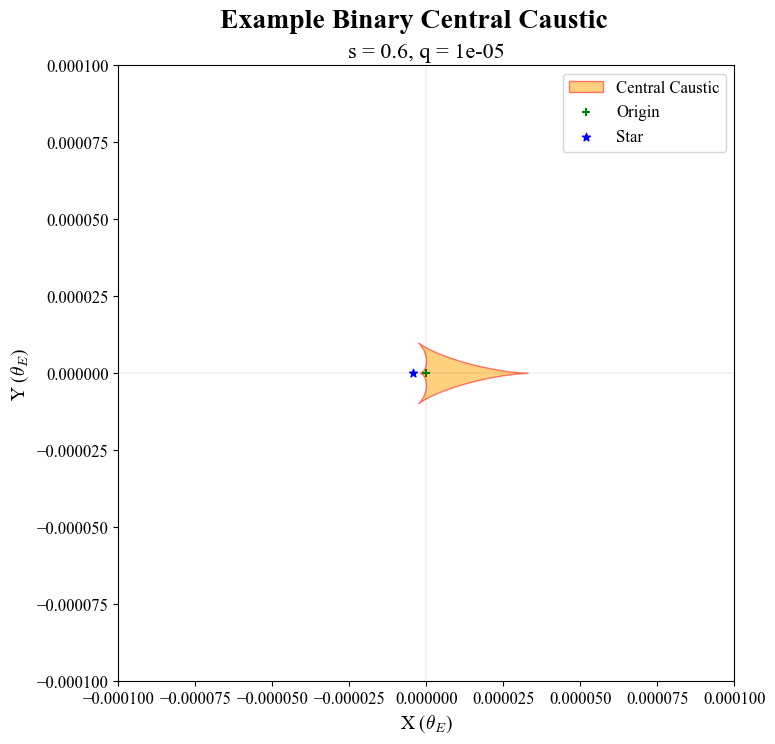

In [3]:
s = 0.6
q = 1e-5

lens_attributes = np.array([
    [0, 0, 1],
    [s, 0, q]
])

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = center_of_magnification

lens_attributes[:, :2] -= desired_offset

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
ax.add_patch(fpr)

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

ax.set_aspect('equal')

view = 0.0001
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f's = {s}, q = {q}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend()

# fig.savefig('Example 1.png', dpi=300)

plt.show()

Pixels: 2289, Angular Width: 0.0008044578088226468, Max Source Radius: 0.00017578124999999994, Min Source Radius: 1.7578124999999993e-06


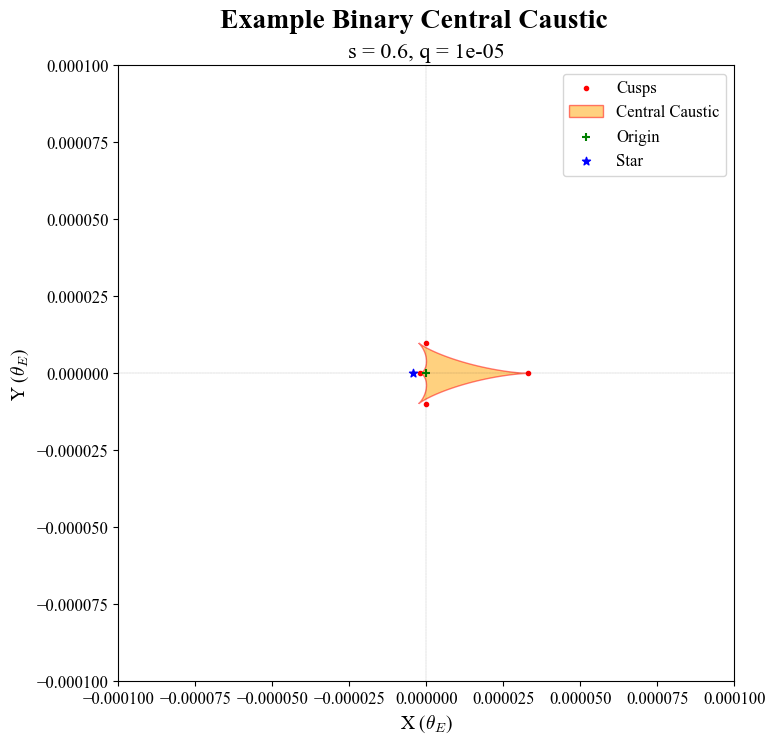

In [4]:
pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = ang_width_calculator(lens_attributes, pixels_in_small_source=10, cm_offset='auto', cm_translation=center_of_magnification)
print(f'Pixels: {pixels}, Angular Width: {ang_width}, Max Source Radius: {max_source_radius}, Min Source Radius: {min_source_radius}')

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

for caustic_points in cusp_points:
    ax.scatter(caustic_points[:, 0], caustic_points[:, 1], color='red', marker='.', label='Cusps')

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
ax.add_patch(fpr)

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

ax.set_aspect('equal')

view = 0.0001
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f's = {s}, q = {q}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend()

# fig.savefig('Example 2.png', dpi=300)

plt.show()

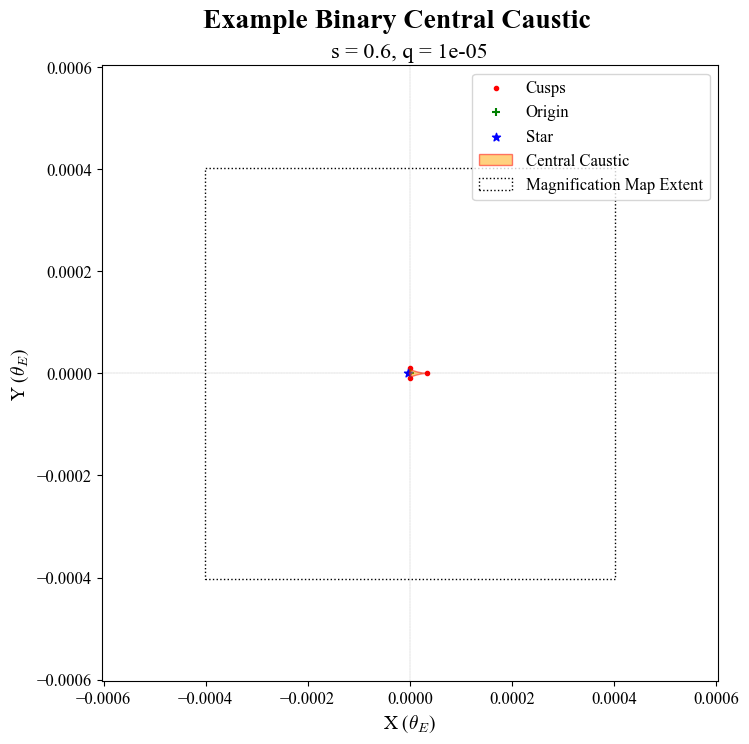

In [5]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

for caustic_points in cusp_points:
    ax.scatter(caustic_points[:, 0], caustic_points[:, 1], color='red', marker='.', label='Cusps')

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)

map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

ax.set_aspect('equal')

view = 1.5*ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f's = {s}, q = {q}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.add_patch(fpr)
ax.add_patch(map_patch)

ax.legend()

# fig.savefig('Example 3.png', dpi=300)

plt.show()

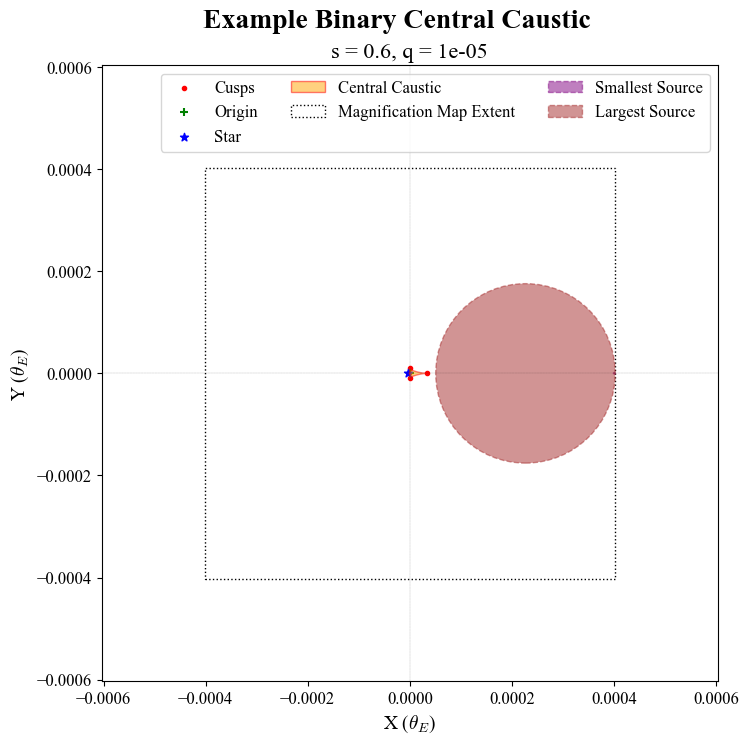

In [6]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

for caustic_points in cusp_points:
    ax.scatter(caustic_points[:, 0], caustic_points[:, 1], color='red', marker='.', label='Cusps')

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')
small_source_patch = patches.Circle((ang_width/2 - min_source_radius, 0), radius=min_source_radius, facecolor='purple', edgecolor='purple', linestyle='--', alpha=0.5, label='Smallest Source')
large_source_patch = patches.Circle((ang_width/2 - max_source_radius, 0), radius=max_source_radius, facecolor='brown', edgecolor='brown', linestyle='--', alpha=0.5, label='Largest Source')

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

ax.set_aspect('equal')

view = 1.5*ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f's = {s}, q = {q}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.add_patch(fpr)
ax.add_patch(map_patch)
ax.add_patch(small_source_patch)
ax.add_patch(large_source_patch)

ax.legend(ncol=3)

# fig.savefig('Example 4.png', dpi=300)

plt.show()

[[[-2.06797059e-06  0.00000000e+00]
  [ 3.30882794e-05  0.00000000e+00]
  [ 0.00000000e+00  9.84899884e-06]
  [ 0.00000000e+00 -9.84899884e-06]]]


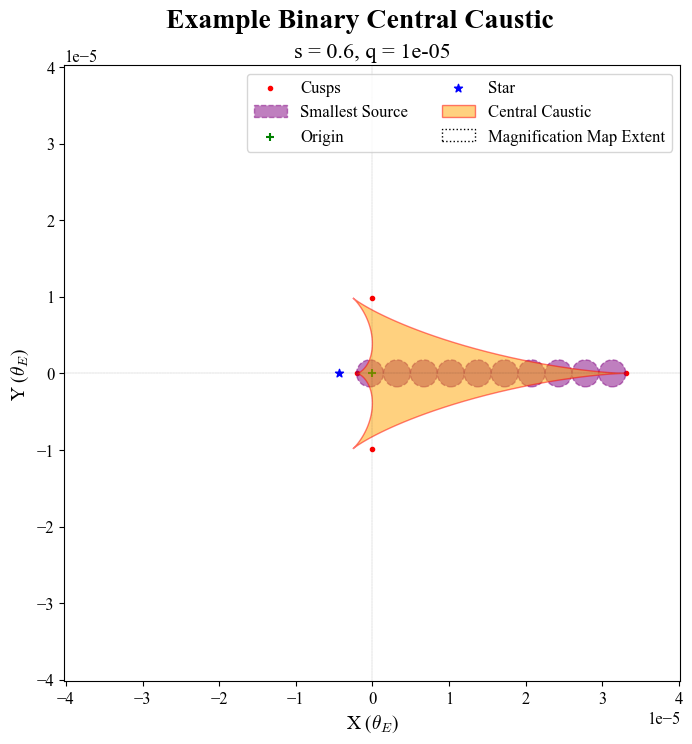

In [7]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

print(cusp_points)

for caustic_points in cusp_points:
    ax.scatter(caustic_points[:, 0], caustic_points[:, 1], color='red', marker='.', label='Cusps')

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

for i in range(10):
    if i == 0:
        small_source_patch = patches.Circle((-2.06797059e-06 + min_source_radius + min_source_radius*2*i, 0), radius=min_source_radius, facecolor='purple', edgecolor='purple', linestyle='--', alpha=0.5, label='Smallest Source')
    else:
        small_source_patch = patches.Circle((-2.06797059e-06 + min_source_radius + min_source_radius*2*i, 0), radius=min_source_radius, facecolor='purple', edgecolor='purple', linestyle='--', alpha=0.5)
    ax.add_patch(small_source_patch)
# large_source_patch = patches.Circle((ang_width/2 - max_source_radius, 0), radius=max_source_radius, facecolor='brown', edgecolor='brown', linestyle='--', alpha=0.5, label='Largest Source')

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

ax.set_aspect('equal')

view = ang_width/20
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f's = {s}, q = {q}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.add_patch(fpr)
ax.add_patch(map_patch)
# ax.add_patch(large_source_patch)

ax.legend(ncol=2)

# fig.savefig('Example 5.png', dpi=300)

plt.show()

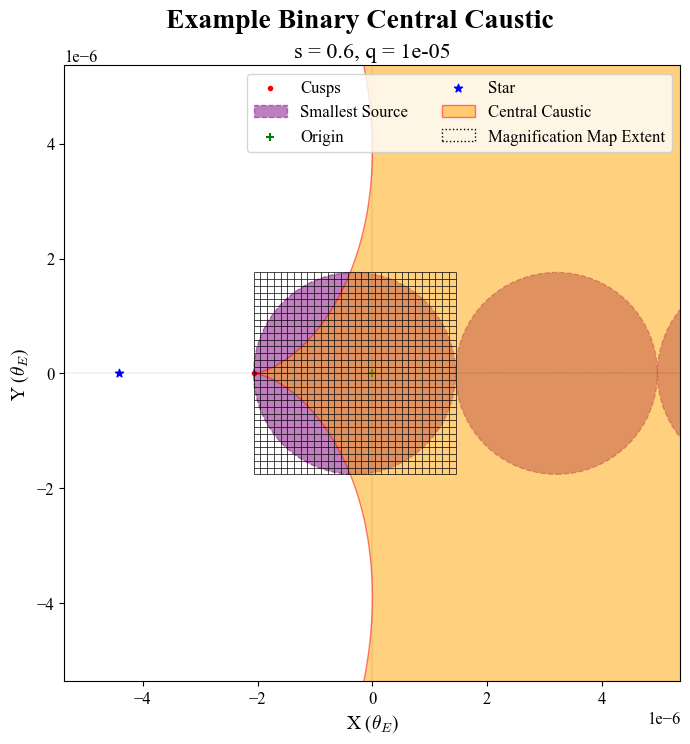

In [8]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

for caustic_points in cusp_points:
    ax.scatter(caustic_points[:, 0], caustic_points[:, 1], color='red', marker='.', label='Cusps')

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

for i in range(10):
    if i == 0:
        small_source_patch = patches.Circle((-2.06797059e-06 + min_source_radius + min_source_radius*2*i, 0), radius=min_source_radius, facecolor='purple', edgecolor='purple', linestyle='--', alpha=0.5, label='Smallest Source')
    else:
        small_source_patch = patches.Circle((-2.06797059e-06 + min_source_radius + min_source_radius*2*i, 0), radius=min_source_radius, facecolor='purple', edgecolor='purple', linestyle='--', alpha=0.5)
    ax.add_patch(small_source_patch)
# large_source_patch = patches.Circle((ang_width/2 - max_source_radius, 0), radius=max_source_radius, facecolor='brown', edgecolor='brown', linestyle='--', alpha=0.5, label='Largest Source')

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

xs = np.linspace(-2.06797059e-06, -2.06797059e-06 + 2*min_source_radius, 31)
ys = np.linspace(-min_source_radius, min_source_radius, 31)

ax.hlines(ys, -2.06797059e-06, -2.06797059e-06 + 2*min_source_radius, colors='black', linestyles='-', linewidth=0.5, alpha=1)
ax.vlines(xs, -min_source_radius, min_source_radius, colors='black', linestyles='-', linewidth=0.5, alpha=1)

ax.set_aspect('equal')

view = ang_width/150
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f's = {s}, q = {q}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.add_patch(fpr)
ax.add_patch(map_patch)
# ax.add_patch(large_source_patch)

ax.legend(ncol=2)

# fig.savefig('Example 6.png', dpi=300)

plt.show()

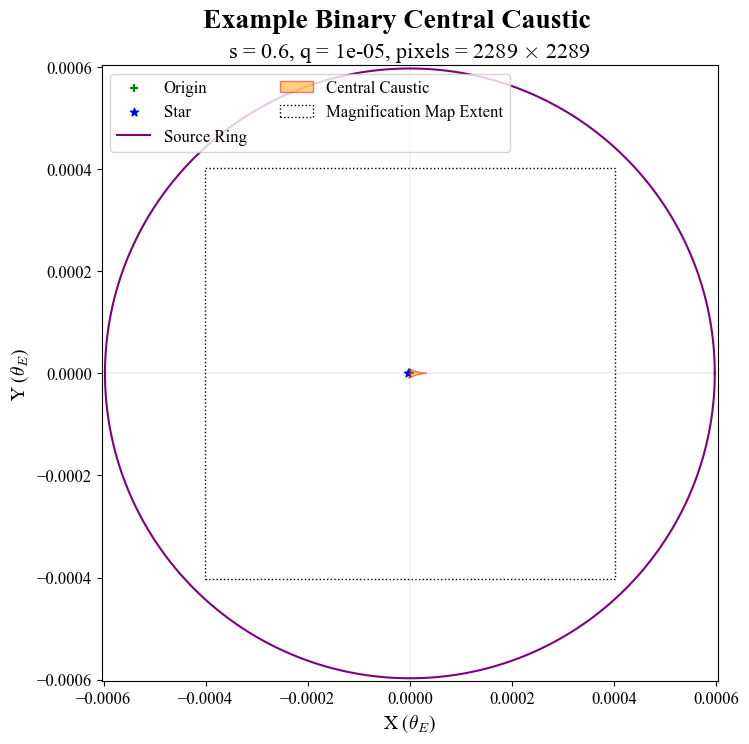

In [9]:
u = 1.05 * ang_width / np.sqrt(2)

# Defining ring slightly larger than magnification map extent
thetas = np.linspace(0, 2*np.pi, 10000, endpoint=True)
xs = u * np.cos(thetas)
ys = u * np.sin(thetas)

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

ax.plot(xs, ys, color='purple', label='Source Ring')

ax.set_aspect('equal')

view = 1.5 * ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f's = {s}, q = {q}, pixels = {pixels} $\\times$ {pixels}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.add_patch(fpr)
ax.add_patch(map_patch)

ax.legend(ncol=2, loc='upper left')

# fig.savefig('Example 7.png', dpi=300)

plt.show()

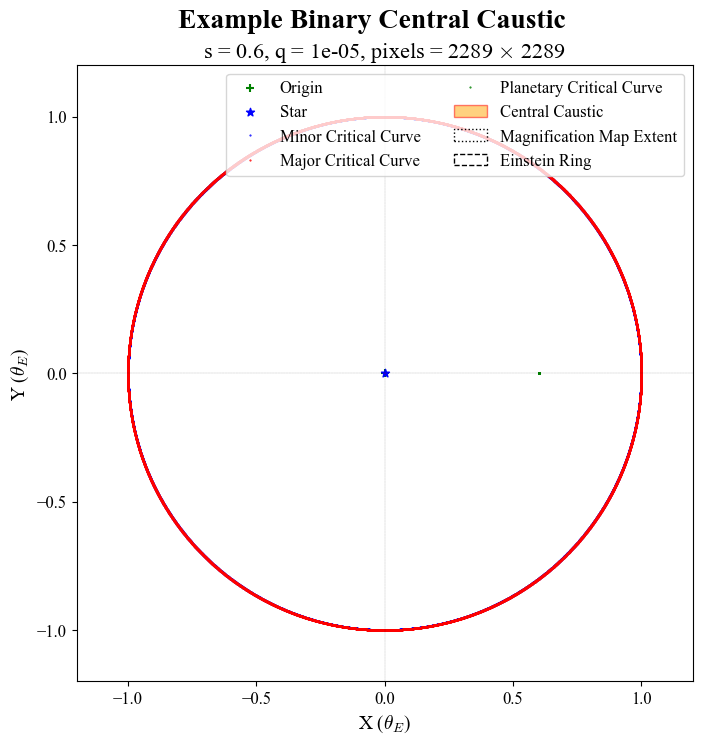

In [10]:
model = _MyBinaryLens(q=q, s=s)
all_points = []
ring_magnifications = []

for x, y in zip(xs, ys):
    magnification, image_positions = model.get_n_images(x - center_of_mass[0], y - center_of_mass[1])

    for image_position in image_positions:
        all_points.append([image_position.real, image_position.imag])

    ring_magnifications.append(magnification)

all_points = np.array(all_points)
ring_magnifications = np.array(ring_magnifications)

offset_circle, small_circle, large_circle = _separate_circles(all_points, q, s)

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

ax.plot(small_circle[:, 0], small_circle[:, 1], color='b', marker='.', linestyle='None', markersize=1, label='Minor Critical Curve')
ax.plot(large_circle[:, 0], large_circle[:, 1], color='r', marker='.', linestyle='None', markersize=1, label='Major Critical Curve')
ax.plot(offset_circle[:, 0], offset_circle[:, 1], color='g', marker='.', linestyle='None', markersize=1, label='Planetary Critical Curve')

ax.set_aspect('equal')

view = 1.2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f's = {s}, q = {q}, pixels = {pixels} $\\times$ {pixels}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.add_patch(fpr)
ax.add_patch(map_patch)
ax.add_patch(ring_patch)

ax.legend(ncol=2)

# fig.savefig('Example 8.png', dpi=300)

plt.show()

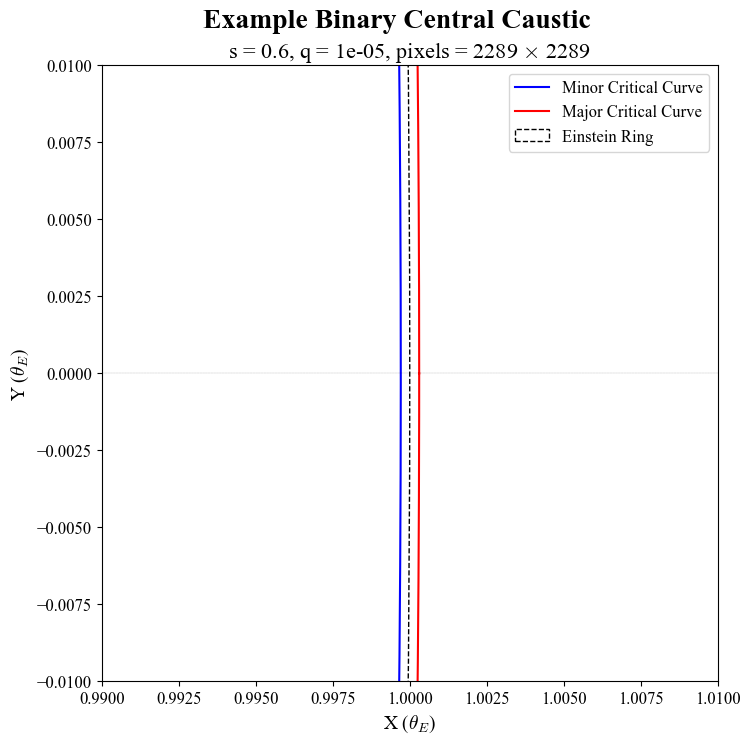

In [11]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')

# ax.scatter(0, 0, color='green', marker='+', label='Origin')
# ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

ax.plot(small_circle[:, 0], small_circle[:, 1], color='b', linestyle='-', markersize=1, label='Minor Critical Curve')
ax.plot(large_circle[:, 0], large_circle[:, 1], color='r', linestyle='-', markersize=1, label='Major Critical Curve')
# ax.plot(offset_circle[:, 0], offset_circle[:, 1], color='g', linestyle='-', markersize=1, label='Planetary Critical Curve')

ax.set_aspect('equal')

view = 1.2
ax.set_xlim(0.99, 1.01)
ax.set_ylim(-0.01, 0.01)

ax.set_title(f's = {s}, q = {q}, pixels = {pixels} $\\times$ {pixels}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# ax.add_patch(fpr)
# ax.add_patch(map_patch)
ax.add_patch(ring_patch)

ax.legend(ncol=1)

# fig.savefig('Example 9.png', dpi=300)

plt.show()

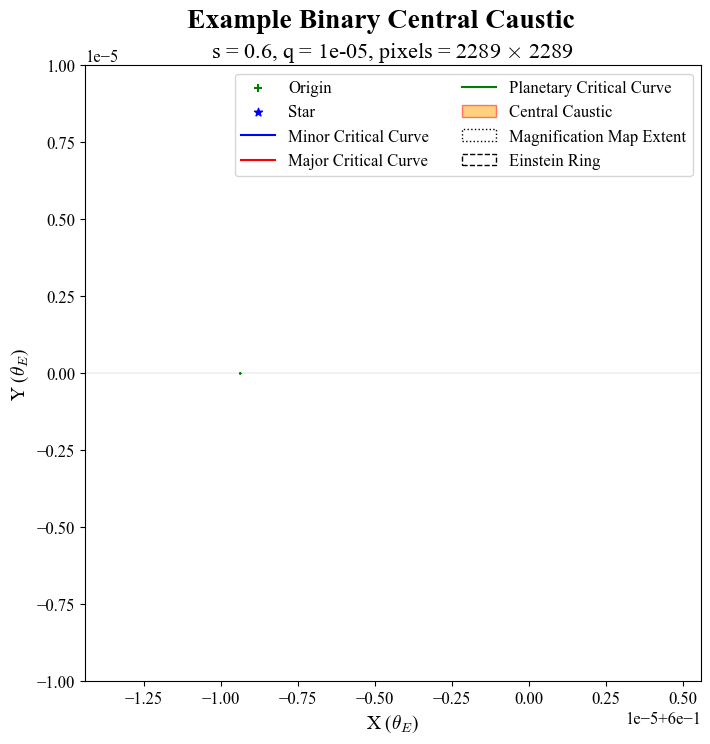

In [12]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')

ax.plot(small_circle[:, 0], small_circle[:, 1], color='b', linestyle='-', markersize=1, label='Minor Critical Curve')
ax.plot(large_circle[:, 0], large_circle[:, 1], color='r', linestyle='-', markersize=1, label='Major Critical Curve')
ax.plot(offset_circle[:, 0], offset_circle[:, 1], color='g', linestyle='-', markersize=1, label='Planetary Critical Curve')

ax.set_aspect('equal')

view = 1.2
center = 0.6 - center_of_magnification[0]
delta = 1e-5
ax.set_xlim(center - delta, center + delta)
ax.set_ylim(-delta, delta)

ax.set_title(f's = {s}, q = {q}, pixels = {pixels} $\\times$ {pixels}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.add_patch(fpr)
ax.add_patch(map_patch)
ax.add_patch(ring_patch)

ax.legend(ncol=2)

# fig.savefig('Example 10.png', dpi=300)

plt.show()

Annulus bounds: y+ = 1.0003002003682282, y- = 0.9996998898692948, Min Magnification in Annulus = 1613.2958098618165
Number of rays: num_r = 869772, num_theta = 217443
Total number of rays: 1.891e+11


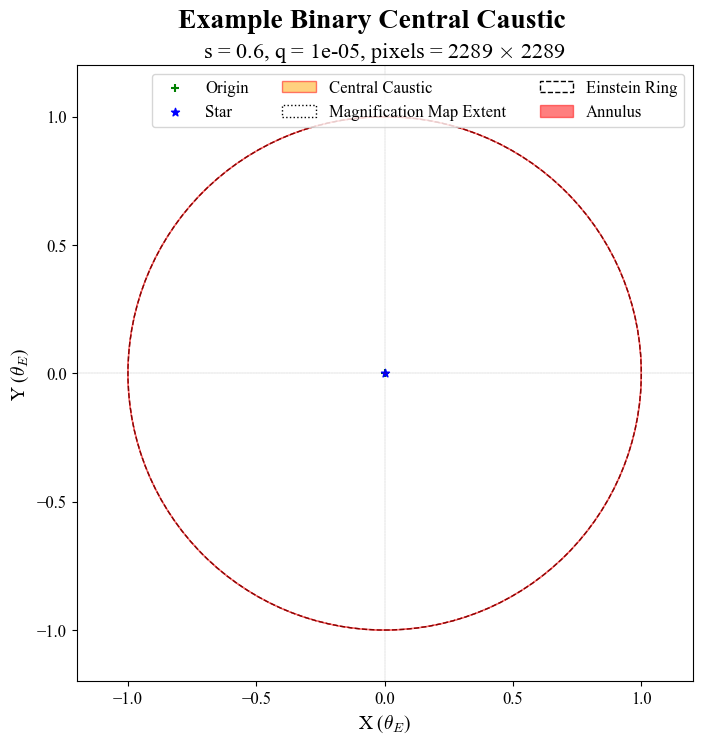

In [13]:
(y_plus, y_minus), min_mag = annulus_bounds_calculator(ang_width, qs, ss, annulus_center=center_of_magnification)
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

num_r, num_theta = num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

x = caustics[2][0] + center_of_mass[0] - desired_offset[0]
y = caustics[2][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x, y]).T

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')

annulus_patch = patches.Annulus(-center_of_magnification, y_plus, y_plus - y_minus, edgecolor='red', facecolor='red', alpha=0.5, linestyle='-', label='Annulus')

ax.scatter(0, 0, color='green', marker='+', label='Origin')
ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star')


ax.set_aspect('equal')

view = 1.2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f's = {s}, q = {q}, pixels = {pixels} $\\times$ {pixels}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.add_patch(fpr)
ax.add_patch(map_patch)
ax.add_patch(ring_patch)
ax.add_patch(annulus_patch)

ax.legend(ncol=3)

# fig.savefig('Example 11.png', dpi=300)

plt.show()

In [14]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': 3.5 * ang_width/2,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': lens_attributes.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim_big = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications_big = sim_big.series_calculate(cm_offset='auto', annulus_offset=desired_offset)

100%|██████████| 500/500 [00:03<00:00, 145.56it/s]

---------------------
Total time: 3.551 seconds


/var/folders/39/mb5cwg0x4h18n1y377g5rs9c0000gn/T/ipykernel_78945/1247287442.py:9: RuntimeWarning: divide by zero encountered in log10
  plot = ax.imshow(np.log10(magnifications_big),


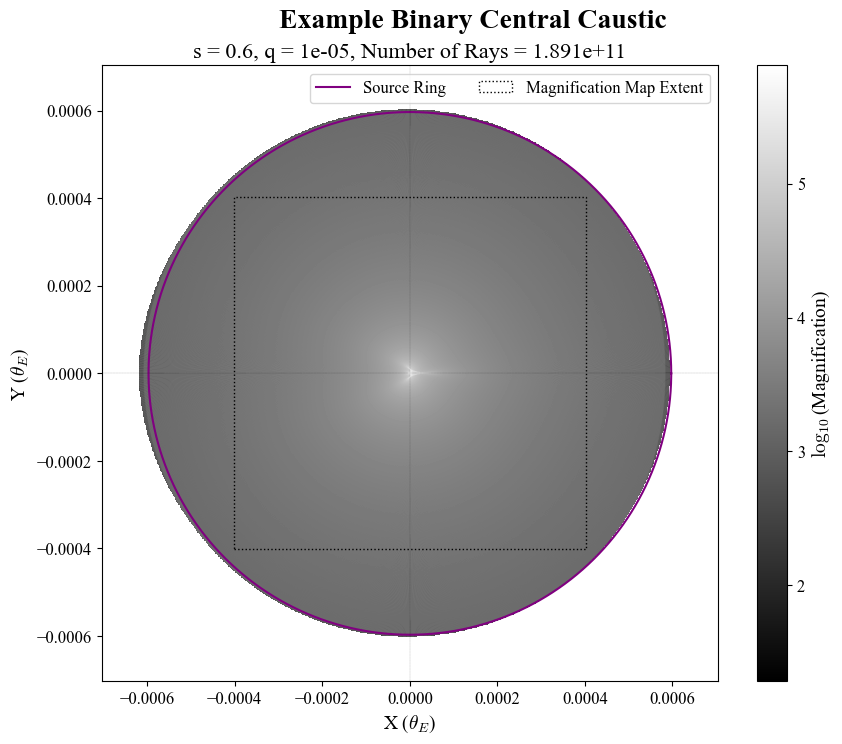

In [15]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

plot = ax.imshow(np.log10(magnifications_big), 
                 cmap='gray', 
                 extent=[-sim_big.ang_width/2 - sim_big.ang_res/2, sim_big.ang_width/2 + sim_big.ang_res/2, -sim_big.ang_width/2 - sim_big.ang_res/2, sim_big.ang_width/2 + sim_big.ang_res/2]
)
bar = plt.colorbar(plot)
bar.set_label(r'$\log_{10}$(Magnification)')

# ax.scatter(0, 0, color='green', marker='+', label='Origin', s=2)
# ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star', s=1)

ax.plot(xs, ys, color='purple', label='Source Ring')

ax.set_title(f's = {s}, q = {q}, Number of Rays = {num_r * num_theta:.3e}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = sim_big.ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# ax.add_patch(fpr)
ax.add_patch(map_patch)

ax.legend(ncol=2, loc='upper right')

# fig.savefig('Example 12.png', dpi=300)

plt.show()

In [16]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': lens_attributes.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications = sim.series_calculate(cm_offset='auto', annulus_offset=center_of_magnification)

100%|██████████| 500/500 [00:03<00:00, 146.79it/s]

---------------------
Total time: 3.414 seconds


Plotting magnification map: 0.047 seconds


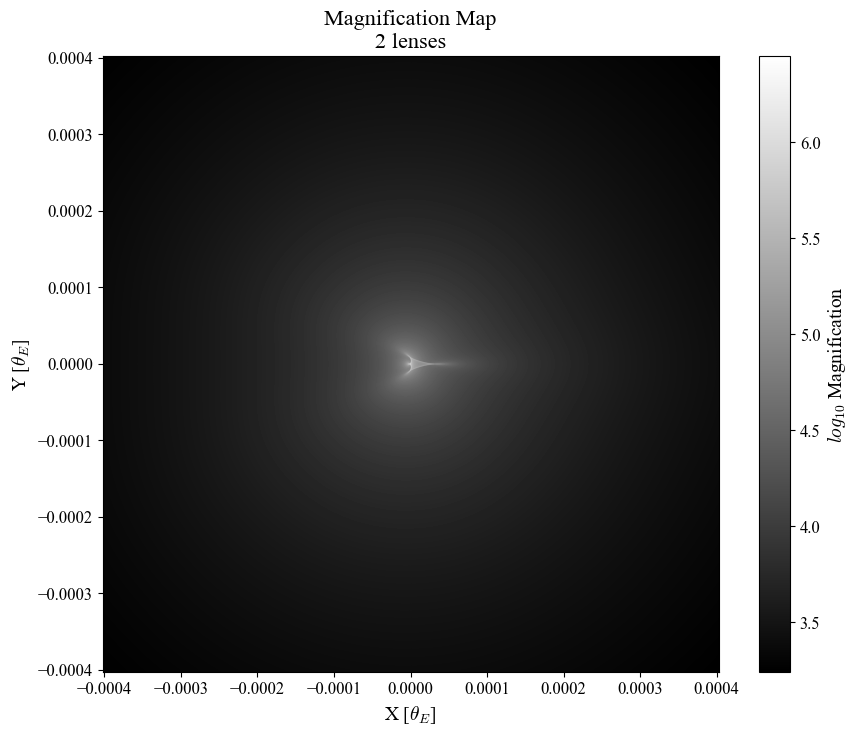

In [17]:
sim = IRSC.caustic_reader('../Roman F2F Conference 2/binary_example.pkl')
sim.plot()

magnifications = sim.magnifications

plt.show()

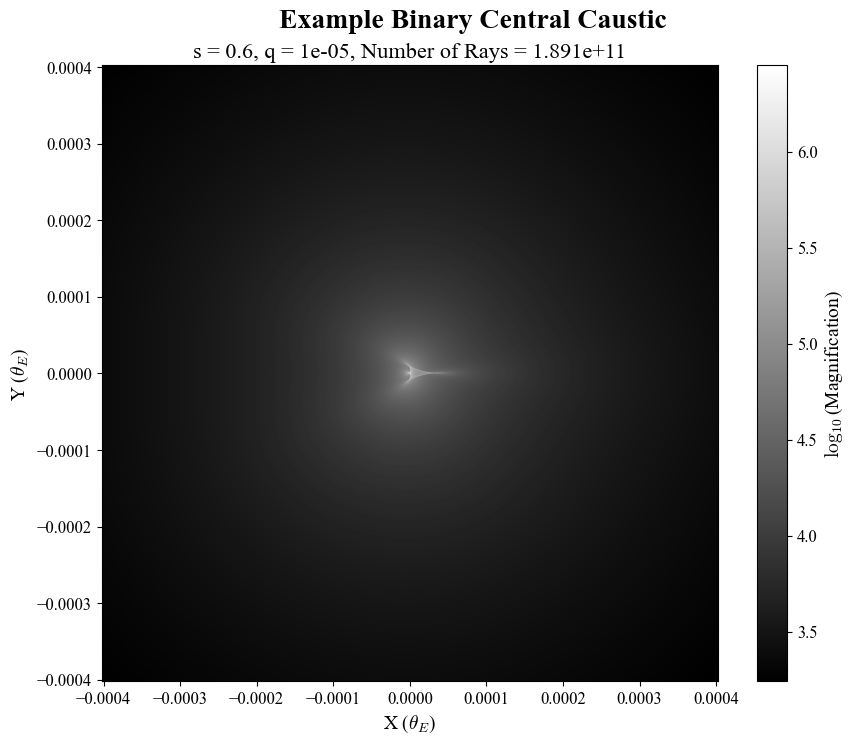

In [20]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

fpr = patches.Polygon(points, closed=False, fill=True, edgecolor='red', label='Central Caustic', facecolor='orange', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

plot = ax.imshow(np.log10(magnifications), 
                 cmap='gray', 
                 extent=[-sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2, -sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2]
)
bar = plt.colorbar(plot)
bar.set_label(r'$\log_{10}$(Magnification)')

# ax.scatter(0, 0, color='green', marker='+', label='Origin', s=2)
# ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star', s=1)

# ax.plot(xs, ys, color='purple', label='Source Ring')

ax.set_title(f's = {s}, q = {q}, Number of Rays = {sim.num_r * sim.num_theta:.3e}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = sim.ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

# ax.hlines(0, -view, view, colors='white', linestyles='dashed', linewidth=0.1)
# ax.vlines(0, -view, view, colors='white', linestyles='dashed', linewidth=0.1)

# ax.add_patch(fpr)
# ax.add_patch(map_patch)

# ax.legend(ncol=2, loc='upper right')

# fig.savefig('Example 13.png', dpi=300)
fig.savefig('GRFP.png', dpi=300)

plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Binary Central Caustic', y=0.95)

fpr = patches.Polygon(points, closed=False, fill=False, edgecolor='red', label='Central Caustic', alpha=0.5)
map_patch = patches.Rectangle((-ang_width/2, -ang_width/2), ang_width, ang_width, fill=None, edgecolor='black', linestyle=':', label='Magnification Map Extent')

plot = ax.imshow(np.log10(magnifications), 
                 cmap='gray', 
                 extent=[-sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2, -sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2]
)
bar = plt.colorbar(plot)
bar.set_label(r'$\log_{10}$(Magnification)')

# ax.scatter(0, 0, color='green', marker='+', label='Origin', s=2)
# ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1], color='blue', marker='*', label='Star', s=1)

# ax.plot(xs, ys, color='purple', label='Source Ring')

ax.set_title(f's = {s}, q = {q}, Number of Rays = {num_r * num_theta:.3e}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = sim.ang_width/10
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.hlines(0, -view, view, colors='white', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='white', linestyles='dashed', linewidth=0.1)

ax.add_patch(fpr)
# ax.add_patch(map_patch)

ax.legend(ncol=2, loc='upper right')

# fig.savefig('Example 14.png', dpi=300)

plt.show()

In [ ]:
single_lens_attributes = np.array([
    [0, 0, 1]
])        

(y_plus, y_minus), min_mag = annulus_bounds_calculator(ang_width, qs=None, ss=None)
num_r, num_theta = num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)

print(f'Number of rays for single lens: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays for single lens: {(num_r * num_theta):.3e}')
print(f'y_plus = {y_plus}, y_minus = {y_minus}, min_mag = {min_mag}')
print(f'Angular width = {ang_width}, Pixels = {pixels}')

In [ ]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': single_lens_attributes.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

single_sim = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
single_magnifications = single_sim.series_calculate(cm_offset='auto', annulus_offset=desired_offset)

In [ ]:
single_sim = IRSC.caustic_reader('../Roman F2F Conference 2/single_example.pkl')
single_sim.plot()

single_magnifications = single_sim.magnifications

plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Single Caustic', y=0.95)

plot = ax.imshow(np.log10(single_magnifications), 
                 cmap='gray', 
                 extent=[-single_sim.ang_width/2 - single_sim.ang_res/2, single_sim.ang_width/2 + single_sim.ang_res/2, -single_sim.ang_width/2 - single_sim.ang_res/2, single_sim.ang_width/2 + single_sim.ang_res/2]
)
bar = plt.colorbar(plot)
bar.set_label(r'$\log_{10}$(Magnification)')

ax.set_title(f'Number of Rays = {num_r * num_theta:.3e}')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = single_sim.ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.hlines(0, -view, view, colors='white', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='white', linestyles='dashed', linewidth=0.1)

# fig.savefig('Example 15.png', dpi=300)

plt.show()

In [ ]:
rad = 1e-4
source_profile = IRSF.IRSFunctions.source_profile(single_sim.ang_res, rad=rad, profile_type='LD', LD=0.5, supersample=10)

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Example Source Profile', y=0.95)

plot = ax.imshow(source_profile, 
                 cmap='afmhot',
                 extent=[-max_source_radius, max_source_radius, -max_source_radius, max_source_radius]
)
bar = plt.colorbar(plot)
bar.set_label('Normalized Intensity')

ax.set_aspect('equal')
ax.set_title(f'Source Radius = {rad:.3e} $\\theta_E$, $\Gamma_\lambda = 0.5$')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

# fig.savefig('Example 16.png', dpi=300)

plt.show()

In [ ]:
single_convolved_brightnesses = single_sim.convolve(source_profile)
binary_convolved_brightnesses = sim.convolve(source_profile)

fig = plt.figure(figsize=(18, 8))
axes = fig.subplots(1, 2, sharex=True, sharey=True)

fig.suptitle('Convolved Magnification Maps', y=0.95)

axes[0].set_title('Single Lens Convolved Magnification Map')
plot1 = axes[0].imshow(np.log10(single_convolved_brightnesses), 
                       cmap='gray', 
                       extent=[-single_sim.ang_width/2 - single_sim.ang_res/2, single_sim.ang_width/2 + single_sim.ang_res/2, -single_sim.ang_width/2 - single_sim.ang_res/2, single_sim.ang_width/2 + single_sim.ang_res/2]
)
bar1 = plt.colorbar(plot1, ax=axes[0])
bar1.set_label(r'$\log_{10}$(Convolved Magnification)')

axes[1].set_title('Binary Lens Convolved Magnification Map')
plot2 = axes[1].imshow(np.log10(binary_convolved_brightnesses), 
                       cmap='gray', 
                       extent=[-sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2, -sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2]
)
bar2 = plt.colorbar(plot2, ax=axes[1])
bar2.set_label(r'$\log_{10}$(Convolved Magnification)')

axes[0].set_xlabel(r'X ($\theta_E$)')
axes[0].set_ylabel(r'Y ($\theta_E$)')
axes[1].set_xlabel(r'X ($\theta_E$)')
axes[1].set_ylabel(r'Y ($\theta_E$)')

# fig.savefig('Example 17.png', dpi=300)

plt.show()


In [ ]:
fractional_difference = (binary_convolved_brightnesses - single_convolved_brightnesses) / single_convolved_brightnesses

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Fractional Difference Between Convolved Magnification Maps', y=0.95)

plot = ax.imshow(fractional_difference, 
                 cmap='gray',
                 extent=[-sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2, -sim.ang_width/2 - sim.ang_res/2, sim.ang_width/2 + sim.ang_res/2],
)
plot = ax.contour(fractional_difference,
           levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
           colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'green', 'red', 'red', 'red', 'red', 'red', 'red'],
           linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.5, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
           extent=[-sim.ang_width/2, sim.ang_width/2, -sim.ang_width/2, sim.ang_width/2]
)

bar = plt.colorbar(plot)
bar.set_label('Fractional Difference')

ax.set_title(f's = {s}, q = {q}, Source Radius = {rad:.3e} $\\theta_E$')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = sim.ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# fig.savefig('Example 18.png', dpi=300)
plt.show()

Simulate the following lens configurations:
- Binary lens: Sun + Jupiter
- Triple lens: Sun + Jupiter + Saturn (inside Einstein ring)
- 5 lenses: Sun + Jupiter + Saturn (inside Einstein ring) + Uranus + Earth (inside Einstein ring)

Calculate the following fractional deviations:
- Error between triple and binary lens
- Error between 5-lens and triple lens

Plot the cumulative distribution for triple-binary fractional deviation

In [ ]:
import astropy.units as u
import astropy.constants as c

# Distance to source plane
D_s = 8 * u.kpc

# Distance to lens plane
D_l = 4 * u.kpc

theta_ein, r_ein = IRSF.IRSFunctions.e_ring([D_s, D_l], 1)

r_jup = 5.2 * u.au
r_saturn = 9.5 * u.au
r_earth = 1 * u.au
r_uranus = 19.2 * u.au

s_jup = (r_jup / r_ein).to(u.dimensionless_unscaled).value
s_saturn = (r_saturn / r_ein).to(u.dimensionless_unscaled).value
s_earth = (r_earth / r_ein).to(u.dimensionless_unscaled).value
s_uranus = (r_uranus / r_ein).to(u.dimensionless_unscaled).value

q_jup = (c.M_jup / c.M_sun).to(u.dimensionless_unscaled).value
q_saturn = (5.683e26 * u.kg / c.M_sun).to(u.dimensionless_unscaled).value
q_earth = (c.M_earth / c.M_sun).to(u.dimensionless_unscaled).value
q_uranus = (8.681e25 * u.kg / c.M_sun).to(u.dimensionless_unscaled).value

print(f's_jup = {s_jup:.3f}')
print(f's_saturn = {s_saturn:.3f}')
print(f's_earth = {s_earth:.3f}')
print(f's_uranus = {s_uranus:.3f}')

print(f'q_jup = {q_jup:.3e}')
print(f'q_saturn = {q_saturn:.3e}')
print(f'q_earth = {q_earth:.3e}')
print(f'q_uranus = {q_uranus:.3e}')

Sun + Jupiter

In [ ]:
sun_jupiter_lens_att = np.array([
    [0, 0, 1],
    [s_jup, 0, q_jup]
])

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = ang_width_calculator(sun_jupiter_lens_att, pixels_in_small_source=10, cm_offset='auto')
print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

(y_plus, y_minus), min_mag = annulus_bounds_calculator(ang_width, qs, ss)
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

num_r, num_theta = num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

In [ ]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': sun_jupiter_lens_att.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim_sun_jupiter = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications_sun_jupiter = sim_sun_jupiter.series_calculate(cm_offset='auto')

In [ ]:
sim_sun_jupiter = IRSC.caustic_reader('../Roman F2F Conference 2/sun_jupiter_example.pkl')
sim_sun_jupiter.plot()

magnifications_sun_jupiter = sim_sun_jupiter.magnifications

plt.show()

Sun + Jupiter + Saturn

In [ ]:
alpha_saturn = np.deg2rad(-45)
s_saturn = 0.8

sun_jupiter_saturn_lens_att = np.array([
    [0, 0, 1],
    [s_jup, 0, q_jup],
    [s_saturn * np.cos(alpha_saturn), s_saturn * np.sin(alpha_saturn), q_saturn]
])

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = ang_width_calculator(sun_jupiter_saturn_lens_att, pixels_in_small_source=10, cm_offset='auto')
print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

(y_plus, y_minus), min_mag = annulus_bounds_calculator(ang_width, qs, ss)
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

num_r, num_theta = num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

In [ ]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': sun_jupiter_saturn_lens_att.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim_sun_jupiter_saturn = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications_sun_jupiter_saturn = sim_sun_jupiter_saturn.series_calculate(cm_offset='auto')

In [ ]:
sim_sun_jupiter_saturn = IRSC.caustic_reader('../Roman F2F Conference 2/sun_jupiter_saturn_example.pkl')
sim_sun_jupiter_saturn.plot()

magnifications_sun_jupiter_saturn = sim_sun_jupiter_saturn.magnifications

plt.show()

Sun + Jupiter + Saturn + Uranus

In [ ]:
alpha_uranus = -120

four_lens_att = np.array([
    [0, 0, 1],
    [s_jup, 0, q_jup],
    [s_saturn * np.cos(alpha_saturn), s_saturn * np.sin(alpha_saturn), q_saturn],
    [s_uranus * np.cos(np.deg2rad(alpha_uranus)), s_uranus * np.sin(np.deg2rad(alpha_uranus)), q_uranus]
])

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = ang_width_calculator(four_lens_att, pixels_in_small_source=10, cm_offset='auto')
print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

(y_plus, y_minus), min_mag = annulus_bounds_calculator(ang_width, qs, ss)
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

num_r, num_theta = num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

In [ ]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': four_lens_att.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim_four_lenses = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications_four_lenses = sim_four_lenses.series_calculate(cm_offset='auto')

In [ ]:
sim_four_lenses = IRSC.caustic_reader('../Roman F2F Conference 2/four_lens_example.pkl')
sim_four_lenses.plot()

magnifications_four_lenses = sim_four_lenses.magnifications

plt.show()

Sun + Jupiter + Saturn + Uranus + Earth

In [ ]:
alpha_earth = 30

five_lens_att = np.array([
    [0, 0, 1],
    [s_jup, 0, q_jup],
    [s_saturn * np.cos(alpha_saturn), s_saturn * np.sin(alpha_saturn), q_saturn],
    [s_earth * np.cos(np.deg2rad(alpha_earth)), s_earth * np.sin(np.deg2rad(alpha_earth)), q_earth],
    [s_uranus * np.cos(np.deg2rad(alpha_uranus)), s_uranus * np.sin(np.deg2rad(alpha_uranus)), q_uranus]
])

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = ang_width_calculator(five_lens_att, pixels_in_small_source=10, cm_offset='auto')
print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

(y_plus, y_minus), min_mag = annulus_bounds_calculator(ang_width, qs, ss)
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

num_r, num_theta = num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Planetary System Lens Configuration', y=0.95)

labels = ['Sun', 'Jupiter', 'Close Saturn', 'Earth', 'Uranus']

for i in range(five_lens_att.shape[0]):
    ax.scatter(five_lens_att[i, 0], five_lens_att[i, 1], label=labels[i], marker='*' if i == 0 else 'o')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')
ax.add_patch(ring_patch)

ax.set_aspect('equal')

ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = 5
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend(ncol=2, loc='upper right')

# fig.savefig('Lens Configuration.png', dpi=300)

plt.show()

In [ ]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': five_lens_att.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim_five_lenses = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications_five_lenses = sim_five_lenses.series_calculate(cm_offset='auto')

In [ ]:
sim_five_lenses = IRSC.caustic_reader('../Roman F2F Conference 2/five_lens_example.pkl')
sim_five_lenses.plot()

magnifications_five_lenses = sim_five_lenses.magnifications

plt.show()

In [ ]:
rad = max_source_radius
source_profile = IRSF.IRSFunctions.source_profile(sim_five_lenses.ang_res, rad=rad, profile_type='LD', LD=0.5, supersample=10)

fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Source Profile', y=0.95)

plot = ax.imshow(source_profile, 
                 cmap='afmhot',
                 extent=[-max_source_radius, max_source_radius, -max_source_radius, max_source_radius]
)
bar = plt.colorbar(plot)
bar.set_label('Normalized Intensity')

ax.set_aspect('equal')
ax.set_title(f'Source Radius = {rad:.3e} $\\theta_E$')
ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

plt.show()

In [ ]:
sun_jupiter_brightnesses = sim_sun_jupiter.convolve(source_profile=source_profile)
sun_jupiter_saturn_brightnesses = sim_sun_jupiter_saturn.convolve(source_profile=source_profile)
four_lens_brightnesses = sim_four_lenses.convolve(source_profile=source_profile)
five_lens_brightnesses = sim_five_lenses.convolve(source_profile=source_profile)

In [ ]:
triple_binary_fractional_difference = (sun_jupiter_saturn_brightnesses - sun_jupiter_brightnesses) / sun_jupiter_brightnesses
five_binary_fractional_difference = (five_lens_brightnesses - sun_jupiter_brightnesses) / sun_jupiter_brightnesses
five_triple_fractional_difference = (five_lens_brightnesses - sun_jupiter_saturn_brightnesses) / sun_jupiter_saturn_brightnesses
five_four_fractional_difference = (five_lens_brightnesses - four_lens_brightnesses) / four_lens_brightnesses

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('(triple - binary) / binary', y=0.95)

img = ax.imshow(triple_binary_fractional_difference, 
          cmap='gray',
          extent=[-sim_sun_jupiter_saturn.ang_width/2 - sim_sun_jupiter_saturn.ang_res/2, sim_sun_jupiter_saturn.ang_width/2 + sim_sun_jupiter_saturn.ang_res/2, -sim_sun_jupiter_saturn.ang_width/2 - sim_sun_jupiter_saturn.ang_res/2, sim_sun_jupiter_saturn.ang_width/2 + sim_sun_jupiter_saturn.ang_res/2],
)
img = ax.contour(np.flip(triple_binary_fractional_difference, axis=0),
           levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
           colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'green', 'red', 'red', 'red', 'red', 'red', 'red'],
           linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.5, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
           extent=[-sim_sun_jupiter_saturn.ang_width/2, sim_sun_jupiter_saturn.ang_width/2, -sim_sun_jupiter_saturn.ang_width/2, sim_sun_jupiter_saturn.ang_width/2]
)

bar = plt.colorbar(img)
bar.set_label('Fractional Difference')

ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = sim_sun_jupiter.ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# fig.savefig('Triple vs Binary Fractional Difference.png', dpi=300)

plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('(five - binary) / binary', y=0.95)

img = ax.imshow(five_binary_fractional_difference, 
          cmap='gray',
          extent=[-sim_sun_jupiter_saturn.ang_width/2 - sim_sun_jupiter_saturn.ang_res/2, sim_sun_jupiter_saturn.ang_width/2 + sim_sun_jupiter_saturn.ang_res/2, -sim_sun_jupiter_saturn.ang_width/2 - sim_sun_jupiter_saturn.ang_res/2, sim_sun_jupiter_saturn.ang_width/2 + sim_sun_jupiter_saturn.ang_res/2],
)
img = ax.contour(np.flip(five_binary_fractional_difference, axis=0),
           levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
           colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'green', 'red', 'red', 'red', 'red', 'red', 'red'],
           linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.5, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
           extent=[-sim_sun_jupiter_saturn.ang_width/2, sim_sun_jupiter_saturn.ang_width/2, -sim_sun_jupiter_saturn.ang_width/2, sim_sun_jupiter_saturn.ang_width/2]
)

# bar = plt.colorbar(img)
# bar.set_label('Fractional Difference')

ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = sim_sun_jupiter.ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# fig.savefig('Five vs Binary Fractional Difference.png', dpi=300)

plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('(five - triple) / triple', y=0.95)

img = ax.imshow(five_triple_fractional_difference, 
          cmap='gray',
          extent=[-sim_sun_jupiter_saturn.ang_width/2 - sim_sun_jupiter_saturn.ang_res/2, sim_sun_jupiter_saturn.ang_width/2 + sim_sun_jupiter_saturn.ang_res/2, -sim_sun_jupiter_saturn.ang_width/2 - sim_sun_jupiter_saturn.ang_res/2, sim_sun_jupiter_saturn.ang_width/2 + sim_sun_jupiter_saturn.ang_res/2],
)
img = ax.contour(np.flip(five_triple_fractional_difference, axis=0),
           levels=[-3e-4, -1e-4, -3e-5, -1e-5, -3e-6, -1e-6, 0, 1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4],
           colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'green', 'red', 'red', 'red', 'red', 'red', 'red'],
           linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.5, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
           extent=[-sim_sun_jupiter_saturn.ang_width/2, sim_sun_jupiter_saturn.ang_width/2, -sim_sun_jupiter_saturn.ang_width/2, sim_sun_jupiter_saturn.ang_width/2]
)

bar = plt.colorbar(img)
bar.set_label('Fractional Difference')

ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = sim_sun_jupiter.ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# fig.savefig('Five vs Triple Fractional Difference.png', dpi=300)

plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('(five - four) / four', y=0.95)

img = ax.imshow(five_four_fractional_difference, 
          cmap='gray',
          extent=[-sim_sun_jupiter_saturn.ang_width/2 - sim_sun_jupiter_saturn.ang_res/2, sim_sun_jupiter_saturn.ang_width/2 + sim_sun_jupiter_saturn.ang_res/2, -sim_sun_jupiter_saturn.ang_width/2 - sim_sun_jupiter_saturn.ang_res/2, sim_sun_jupiter_saturn.ang_width/2 + sim_sun_jupiter_saturn.ang_res/2],
)
img = ax.contour(np.flip(five_four_fractional_difference, axis=0),
           levels=[-1e-5, -3e-6, -1e-6, 0, 1e-6, 3e-6, 1e-5],
           colors=['blue', 'blue', 'blue', 'green', 'red', 'red', 'red'],
           linewidths=[0.7, 0.5, 0.3, 0.5, 0.3, 0.5, 0.7],
           extent=[-sim_sun_jupiter_saturn.ang_width/2, sim_sun_jupiter_saturn.ang_width/2, -sim_sun_jupiter_saturn.ang_width/2, sim_sun_jupiter_saturn.ang_width/2]
)

bar = plt.colorbar(img)
bar.set_label('Fractional Difference')

ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = sim_sun_jupiter.ang_width/2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# fig.savefig('Five vs Four Fractional Difference.png', dpi=300)

plt.show()

Cumulative distributions

In [ ]:
xs = np.logspace(-7, 0, 1000)

triple_binary_cumulative_dist = []
five_binary_cumulative_dist = []
five_triple_cumulative_dist = []
five_four_cumulative_dist = []

for x in xs:
    triple_binary_cumulative_dist.append(np.sum(np.abs(triple_binary_fractional_difference) < x) / (pixels * pixels))
    five_binary_cumulative_dist.append(np.sum(np.abs(five_binary_fractional_difference) < x) / (pixels * pixels))
    five_triple_cumulative_dist.append(np.sum(np.abs(five_triple_fractional_difference) < x) / (pixels * pixels))
    five_four_cumulative_dist.append(np.sum(np.abs(five_four_fractional_difference) < x) / (pixels * pixels))

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Cumulative Distributions of Fractional Differences', y=0.95)

ax.plot(xs, triple_binary_cumulative_dist, color='blue', label='Triple - Binary')
ax.plot(xs, five_binary_cumulative_dist, color='orange', label='Five - Binary', linestyle='--')
ax.plot(xs, five_triple_cumulative_dist, color='green', label='Five - Triple')
ax.plot(xs, five_four_cumulative_dist, color='red', label='Five - Four')

ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Fractional Difference Threshold')
ax.set_ylabel('Fraction of Area')

ax.grid()
ax.legend()

# fig.savefig('Cumulative Distributions.png', dpi=300)

plt.show()